# Manufacturing Production Data Cleaning and Analysis

This notebook cleans, validates, and prepares manufacturing production data for business analysis and reporting. The workflow covers exploratory data analysis (EDA), data quality assessment, data cleaning, validation, feature engineering, technical visualization, and exporting the final cleaned dataset.

## Business Objective

Prepare a reliable and analysis-ready manufacturing dataset that supports accurate reporting of production performance, downtime, scrap rates, shift efficiency, production line performance, machine utilization, and operator productivity.

**Input Dataset:** `manufacturing_data.csv`

**Output Dataset:** `manufacturing_cleaned.csv`

## 1. Import Libraries

Import the required Python libraries for data manipulation, analysis, and visualization.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

## 2. Load Dataset

Load the manufacturing production dataset and perform an initial inspection to verify that the file has been imported successfully.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

# Load the dataset
df = pd.read_csv("manufacturing_data.csv")

# Display the first 5 rows
df.head()

,Production_ID,Date,Production_Line,Shift,Machine_ID,Operator_ID,Product,Planned_Qty,Produced_Qty,Scrap_Qty,Downtime_Minutes,Downtime_Reason,Efficiency_Percent,Scrap_Rate_Percent
0,PRD00001,2025-04-13,Rolling Line,B,MC015,OP013,GP Coil,685,671,14,55,Scheduled Maintenance,93.40,2.04
1,PRD00002,2025-12-15,Cut-to-Length Line,C,MC006,OP009,CR Sheet,501,488,13,0,Scheduled Maintenance,92.00,2.59
2,PRD00003,2025-09-28,Pickling Line,C,MC007,OP010,HR Coil,1903,1829,74,61,Material Shortage,92.00,3.89
3,PRD00004,2025-04-17,Cut-to-Length Line,A,MC004,OP001,HR Sheet,1872,1793,79,84,Quality Inspection,98.40,4.22
4,PRD00005,2025-03-13,Finishing Line,C,MC004,OP006,GI Sheet,1924,1867,57,54,Mechanical Failure,91.60,2.96


In [4]:
# ==========================================
# Dataset Dimensions
# ==========================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 20000
Number of Columns : 14


In [5]:
# ==========================================
# Column Names
# ==========================================

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Production_ID
2. Date
3. Production_Line
4. Shift
5. Machine_ID
6. Operator_ID
7. Product
8. Planned_Qty
9. Produced_Qty
10. Scrap_Qty
11. Downtime_Minutes
12. Downtime_Reason
13. Efficiency_Percent
14. Scrap_Rate_Percent


## 3. Dataset Structure

Inspect the overall structure of the dataset, including column names, data types, non-null values, and memory usage. This step helps identify potential issues before performing exploratory data analysis.

In [6]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Production_ID       20000 non-null  object 
 1   Date                20000 non-null  object 
 2   Production_Line     20000 non-null  object 
 3   Shift               20000 non-null  object 
 4   Machine_ID          20000 non-null  object 
 5   Operator_ID         19850 non-null  object 
 6   Product             20000 non-null  object 
 7   Planned_Qty         20000 non-null  int64  
 8   Produced_Qty        20000 non-null  int64  
 9   Scrap_Qty           20000 non-null  int64  
 10  Downtime_Minutes    20000 non-null  int64  
 11  Downtime_Reason     20000 non-null  object 
 12  Efficiency_Percent  20000 non-null  float64
 13  Scrap_Rate_Percent  20000 non-null  float64
dtypes: float64(2), int64(4), object(8)
memory usage: 2.1+ MB


In [7]:
# ==========================================
# Data Types
# ==========================================

df.dtypes

Production_ID          object
Date                   object
Production_Line        object
Shift                  object
Machine_ID             object
Operator_ID            object
Product                object
Planned_Qty             int64
Produced_Qty            int64
Scrap_Qty               int64
Downtime_Minutes        int64
Downtime_Reason        object
Efficiency_Percent    float64
Scrap_Rate_Percent    float64
dtype: object

In [10]:
# ==========================================
# Column Classification
# ==========================================

numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

categorical_columns = [
    col for col in df.select_dtypes(include=["object"]).columns
    if col != "Date"
]

date_columns = ["Date"]

print(f"Numerical Columns ({len(numerical_columns)}):")
print(numerical_columns)

print("\n" + "-" * 60)

print(f"\nCategorical Columns ({len(categorical_columns)}):")
print(categorical_columns)

print("\n" + "-" * 60)

print(f"\nDate Columns ({len(date_columns)}):")
print(date_columns)

Numerical Columns (6):
['Planned_Qty', 'Produced_Qty', 'Scrap_Qty', 'Downtime_Minutes', 'Efficiency_Percent', 'Scrap_Rate_Percent']

------------------------------------------------------------

Categorical Columns (7):
['Production_ID', 'Production_Line', 'Shift', 'Machine_ID', 'Operator_ID', 'Product', 'Downtime_Reason']

------------------------------------------------------------

Date Columns (1):
['Date']


In [9]:
# ==========================================
# Memory Usage
# ==========================================

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Dataset Memory Usage: {memory_usage:.2f} MB")

Dataset Memory Usage: 9.68 MB


## 4. Exploratory Data Analysis (EDA)

Explore the dataset to understand its structure, distributions, and characteristics before performing any data cleaning. The goal of this section is to identify patterns, detect potential issues, and gain familiarity with the dataset.

### 4.1 Summary Statistics

Generate descriptive statistics for numerical columns to understand the overall distribution, central tendency, and spread of the data.

In [11]:
# ==========================================
# Summary Statistics
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Planned_Qty,20000.00,1504.85,573.05,500.00,1014.00,1511.00,1995.00,2500.00
Produced_Qty,20000.00,1464.36,558.44,-47.00,986.00,1470.00,1942.00,2488.00
Scrap_Qty,20000.00,40.07,25.26,2.00,21.00,34.00,54.00,150.00
Downtime_Minutes,20000.00,51.89,31.24,0.00,28.00,49.00,71.00,180.00
Efficiency_Percent,20000.00,94.54,2.81,85.00,92.80,94.80,96.60,99.00
Scrap_Rate_Percent,20000.00,2.66,1.24,0.40,1.74,2.50,3.45,6.09


### 4.2 Missing Values

Identify missing values across all columns to understand the completeness of the dataset before cleaning.

In [12]:
# ==========================================
# Missing Values
# ==========================================

missing_values = (
    df.isnull()
      .sum()
      .to_frame(name="Missing Values")
)

missing_values["Percentage"] = (
    missing_values["Missing Values"] / len(df) * 100
).round(2)

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

missing_values

,Missing Values,Percentage
Operator_ID,150,0.75
Production_ID,0,0.00
Date,0,0.00
Production_Line,0,0.00
Shift,0,0.00
Machine_ID,0,0.00
Product,0,0.00
Planned_Qty,0,0.00
Produced_Qty,0,0.00
Scrap_Qty,0,0.00


### 4.3 Duplicate Rows

Check for duplicate records that may affect data quality and analysis.

In [13]:
# ==========================================
# Duplicate Rows
# ==========================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 28


### 4.4 Unique Values

Review the number of unique values in each column to better understand the dataset and identify potential high-cardinality features.

In [14]:
# ==========================================
# Unique Values
# ==========================================

unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
Production_ID,19970
Date,365
Production_Line,16
Shift,12
Machine_ID,26
Operator_ID,45
Product,51
Planned_Qty,2001
Produced_Qty,1996
Scrap_Qty,148


### 4.5 Categorical Variable Exploration

Explore categorical variables to understand their categories, frequency distribution, and identify potential inconsistencies before data cleaning.

In [15]:
# ==========================================
# Categorical Variable Exploration
# ==========================================

categorical_columns = [
    "Production_Line",
    "Shift",
    "Machine_ID",
    "Operator_ID",
    "Product",
    "Downtime_Reason"
]

for column in categorical_columns:
    print("=" * 60)
    print(f"{column}")
    print("=" * 60)

    print(f"Unique Values : {df[column].nunique()}")
    print("\nTop Categories:\n")

    print(df[column].value_counts(dropna=False))

    print("\n")

Production_Line
Unique Values : 16

Top Categories:

Production_Line
Rolling Line            4330
Cut-to-Length Line      4126
Slitting Line           3995
Finishing Line          3977
Pickling Line           3555
Slitting Line              4
Finishing Line             2
 Slitting Line             2
 Finishing Line            2
 Finishing Line            1
Pickling Line              1
 Pickling Line             1
Rolling Line               1
 Slitting Line             1
 Rolling Line              1
 Cut-to-Length Line        1
Name: count, dtype: int64


Shift
Unique Values : 12

Top Categories:

Shift
A      7088
B      6571
C      6328
 B        3
 C        2
C         2
 B        1
B         1
 A        1
 C        1
 A        1
A         1
Name: count, dtype: int64


Machine_ID
Unique Values : 26

Top Categories:

Machine_ID
MC005      1046
MC016      1043
MC010      1030
MC012      1024
MC001      1023
MC002      1019
MC006      1014
MC008      1006
MC020      1006
MC013      1000

### 4.6 Numerical Variable Overview

Review the distribution of numerical variables to understand their range and identify potential anomalies before data cleaning.

In [16]:
# ==========================================
# Numerical Variable Overview
# ==========================================

numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:
    print("=" * 60)
    print(column)
    print("=" * 60)

    print(f"Minimum : {df[column].min()}")
    print(f"Maximum : {df[column].max()}")
    print(f"Mean    : {df[column].mean():.2f}")
    print(f"Median  : {df[column].median():.2f}")

    print("\n")

Planned_Qty
Minimum : 500
Maximum : 2500
Mean    : 1504.85
Median  : 1511.00


Produced_Qty
Minimum : -47
Maximum : 2488
Mean    : 1464.36
Median  : 1470.00


Scrap_Qty
Minimum : 2
Maximum : 150
Mean    : 40.07
Median  : 34.00


Downtime_Minutes
Minimum : 0
Maximum : 180
Mean    : 51.89
Median  : 49.00


Efficiency_Percent
Minimum : 85.0
Maximum : 99.0
Mean    : 94.54
Median  : 94.80


Scrap_Rate_Percent
Minimum : 0.4
Maximum : 6.09
Mean    : 2.66
Median  : 2.50




## 5. Data Quality Assessment

Evaluate the dataset against business rules and data quality standards to identify issues that must be resolved before analysis.

### 5.1 Missing Value Assessment

In [17]:
# ==========================================
# Missing Value Assessment
# ==========================================

missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Percentage (%)
Operator_ID,150,0.75


### 5.2 Duplicate Row Assessment

In [18]:
# ==========================================
# Duplicate Row Assessment
# ==========================================

duplicate_rows = df[df.duplicated()]

print(f"Duplicate Rows: {duplicate_rows.shape[0]}")

duplicate_rows.head()

Duplicate Rows: 28


,Production_ID,Date,Production_Line,Shift,Machine_ID,Operator_ID,Product,Planned_Qty,Produced_Qty,Scrap_Qty,Downtime_Minutes,Downtime_Reason,Efficiency_Percent,Scrap_Rate_Percent
10349,PRD02094,2025-04-08,Finishing Line,A,MC015,OP016,Steel Plate,611,593,18,24,Power Failure,97.20,2.95
10736,PRD05937,2025-09-25,Finishing Line,A,MC002,OP003,Steel Strip,1214,1160,54,10,Quality Inspection,97.00,4.45
11418,PRD02029,2025-08-05,Finishing Line,B,MC006,OP022,CR Sheet,991,970,21,16,Power Failure,92.20,2.12
12536,PRD02590,2025-06-13,Slitting Line,B,MC008,OP006,CR Sheet,2479,2437,42,45,Power Failure,93.90,1.69
12727,PRD05903,2025-07-23,Rolling Line,B,MC019,OP028,HR Coil,2182,2141,41,94,Material Shortage,96.40,1.88


### 5.3 Duplicate Production ID Assessment

In [20]:
# ==========================================
# Duplicate Production ID Assessment
# ==========================================

duplicate_ids = df[df["Production_ID"].duplicated(keep=False)]

print(f"Duplicate Production IDs: {duplicate_ids['Production_ID'].nunique()}")

duplicate_ids.sort_values("Production_ID").head(20)

Duplicate Production IDs: 30


,Production_ID,Date,Production_Line,Shift,Machine_ID,Operator_ID,Product,Planned_Qty,Produced_Qty,Scrap_Qty,Downtime_Minutes,Downtime_Reason,Efficiency_Percent,Scrap_Rate_Percent
289,PRD00290,2025-06-02,Cut-to-Length Line,C,MC001,OP004,CR Sheet,1125,1097,28,105,Tool Change,95.90,2.49
16328,PRD00290,2025-06-02,Cut-to-Length Line,C,MC001,OP004,CR Sheet,1125,1097,28,105,Tool Change,95.90,2.49
454,PRD00455,2025-08-25,Slitting Line,B,MC009,OP002,Steel Plate,1448,1421,27,40,Quality Inspection,92.80,1.86
13113,PRD00455,2025-08-25,Slitting Line,B,MC009,OP002,Steel Plate,1448,1421,27,40,Quality Inspection,92.80,1.86
1507,PRD01508,2025-09-02,Pickling Line,A,MC008,OP011,HR Sheet,1814,1765,49,57,Scheduled Maintenance,92.30,2.70
18499,PRD01508,2025-09-02,Pickling Line,A,MC008,OP011,HR Sheet,1814,1765,49,57,Scheduled Maintenance,92.30,2.70
1522,PRD01523,2025-05-26,Finishing Line,A,MC013,OP013,GP Coil,674,660,14,40,Tool Change,95.80,2.08
15998,PRD01523,2025-05-26,Finishing Line,A,MC013,OP013,GP Coil,674,660,14,40,Tool Change,95.80,2.08
1648,PRD01649,2025-06-04,Rolling Line,A,MC019,NaN,CR Coil,1601,1593,8,59,Scheduled Maintenance,95.40,0.50
12435,PRD01649,2025-06-04,Rolling Line,A,MC019,OP027,CR Coil,1601,1593,8,59,Scheduled Maintenance,95.40,0.50


### 5.4 Data Type Assessment

In [21]:
# ==========================================
# Data Type Assessment
# ==========================================

data_type_summary = pd.DataFrame({
    "Column": df.columns,
    "Current Data Type": df.dtypes.values
})

data_type_summary

,Column,Current Data Type
0,Production_ID,object
1,Date,object
2,Production_Line,object
3,Shift,object
4,Machine_ID,object
5,Operator_ID,object
6,Product,object
7,Planned_Qty,int64
8,Produced_Qty,int64
9,Scrap_Qty,int64


### 5.5 Business Rule Validation

In [22]:
# ==========================================
# Business Rule Validation
# ==========================================

business_rules = {
    "Produced_Qty < 0": (df["Produced_Qty"] < 0).sum(),
    "Produced_Qty > Planned_Qty": (df["Produced_Qty"] > df["Planned_Qty"]).sum(),
    "Scrap_Qty > Produced_Qty": (df["Scrap_Qty"] > df["Produced_Qty"]).sum(),
    "Downtime_Minutes < 0": (df["Downtime_Minutes"] < 0).sum(),
    "Efficiency_Percent < 0": (df["Efficiency_Percent"] < 0).sum(),
    "Efficiency_Percent > 100": (df["Efficiency_Percent"] > 100).sum(),
    "Scrap_Rate_Percent < 0": (df["Scrap_Rate_Percent"] < 0).sum(),
    "Scrap_Rate_Percent > 100": (df["Scrap_Rate_Percent"] > 100).sum()
}

pd.DataFrame(
    business_rules.items(),
    columns=["Validation Rule", "Invalid Records"]
)

,Validation Rule,Invalid Records
0,Produced_Qty < 0,5
1,Produced_Qty > Planned_Qty,0
2,Scrap_Qty > Produced_Qty,5
3,Downtime_Minutes < 0,0
4,Efficiency_Percent < 0,0
5,Efficiency_Percent > 100,0
6,Scrap_Rate_Percent < 0,0
7,Scrap_Rate_Percent > 100,0


### 5.6 Leading and Trailing Whitespace Assessment

In [23]:
# ==========================================
# Leading and Trailing Whitespace Assessment
# ==========================================

object_columns = df.select_dtypes(include="object").columns

whitespace_summary = []

for col in object_columns:
    count = (
        df[col]
        .dropna()
        .astype(str)
        .str.match(r"^\s|\s$")
        .sum()
    )

    whitespace_summary.append([col, count])

whitespace_df = pd.DataFrame(
    whitespace_summary,
    columns=["Column", "Rows with Leading/Trailing Spaces"]
)

whitespace_df

,Column,Rows with Leading/Trailing Spaces
0,Production_ID,0
1,Date,0
2,Production_Line,9
3,Shift,9
4,Machine_ID,5
5,Operator_ID,10
6,Product,13
7,Downtime_Reason,3


### 5.7 Text Case Consistency Assessment

In [24]:
# ==========================================
# Text Case Consistency Assessment
# ==========================================

text_columns = [
    "Production_Line",
    "Product",
    "Downtime_Reason"
]

for col in text_columns:
    print("=" * 60)
    print(col)
    print("=" * 60)
    print(sorted(df[col].dropna().unique()))
    print()

Production_Line
[' Cut-to-Length Line ', ' Finishing Line', ' Finishing Line ', ' Pickling Line ', ' Rolling Line', ' Slitting Line', ' Slitting Line ', 'Cut-to-Length Line', 'Finishing Line', 'Finishing Line ', 'Pickling Line', 'Pickling Line ', 'Rolling Line', 'Rolling Line ', 'Slitting Line', 'Slitting Line ']

Product
[' CR Coil', ' CR Coil ', ' CR Sheet', ' CR Sheet ', ' GP Coil ', ' HR Coil', ' HR Sheet', ' HR Sheet ', ' Steel Plate', ' Steel Strip', 'CR COIL', 'CR Coil', 'CR Coil ', 'CR SHEET', 'CR Sheet', 'Cr Coil', 'Cr Sheet', 'GI SHEET', 'GI Sheet', 'GI Sheet ', 'GP COIL', 'GP Coil', 'Gi Sheet', 'Gp Coil', 'HR COIL', 'HR Coil', 'HR SHEET', 'HR Sheet', 'HR Sheet ', 'Hr Coil', 'Hr Sheet', 'STEEL PLATE', 'STEEL STRIP', 'Steel Plate', 'Steel Strip', 'cr cOIL', 'cr coil', 'cr sHEET', 'cr sheet', 'gi sHEET', 'gi sheet', 'gp cOIL', 'gp coil', 'hr cOIL', 'hr coil', 'hr sHEET', 'hr sheet', 'sTEEL pLATE', 'sTEEL sTRIP', 'steel plate', 'steel strip']

Downtime_Reason
[' Mechanical Failu

## 6. Data Cleaning

Clean and standardize the dataset by resolving missing values, duplicates, incorrect data types, inconsistent text formatting, and invalid records identified during the data quality assessment.

In [25]:
# ==========================================
# Create Working Copy
# ==========================================

clean_df = df.copy()

In [26]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

clean_df = clean_df.drop_duplicates()

print(f"Rows after removing duplicates: {clean_df.shape[0]}")

Rows after removing duplicates: 19972


In [62]:
# ==========================================
# Remove Duplicate Production IDs
# ==========================================

clean_df = clean_df.drop_duplicates(
    subset="Production_ID",
    keep="first"
)

print(f"Duplicate Production IDs Remaining: {clean_df['Production_ID'].duplicated().sum()}")

Duplicate Production IDs Remaining: 0


In [69]:
# ==========================================
# Convert Date Data Type
# ==========================================

clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce"
)

print(clean_df["Date"].dtype)

datetime64[ns]


In [85]:
# ==========================================
# Remove Leading and Trailing Spaces
# ==========================================

object_columns = clean_df.select_dtypes(include="object").columns

for col in object_columns:
    clean_df[col] = clean_df[col].str.strip()

In [87]:
# ==========================================
# Standardize Text Values
# ==========================================

# Shift
clean_df["Shift"] = clean_df["Shift"].str.upper()

# Product
clean_df["Product"] = (
    clean_df["Product"]
    .str.lower()
    .replace({
        "hr coil": "HR Coil",
    "HR COIL": "HR Coil",
    "Hr Coil": "HR Coil",
    "hr cOIL": "HR Coil",

    "hr sheet": "HR Sheet",
    "HR SHEET": "HR Sheet",
    "Hr Sheet": "HR Sheet",
    "hr sHEET": "HR Sheet",

    "cr coil": "CR Coil",
    "CR COIL": "CR Coil",
    "Cr Coil": "CR Coil",
    "cr cOIL": "CR Coil",

    "cr sheet": "CR Sheet",
    "CR SHEET": "CR Sheet",
    "Cr Sheet": "CR Sheet",
    "cr sHEET": "CR Sheet",

    "gp coil": "GP Coil",
    "GP COIL": "GP Coil",
    "Gp Coil": "GP Coil",
    "gp cOIL": "GP Coil",

    "gi sheet": "GI Sheet",
    "GI SHEET": "GI Sheet",
    "Gi Sheet": "GI Sheet",
    "gi sHEET": "GI Sheet",

    "steel plate": "Steel Plate",
    "STEEL PLATE": "Steel Plate",
    "sTEEL pLATE": "Steel Plate",

    "steel strip": "Steel Strip",
    "STEEL STRIP": "Steel Strip",
    "sTEEL sTRIP": "Steel Strip"
    })
)

# Production Line
clean_df["Production_Line"] = (
    clean_df["Production_Line"]
    .replace({
        "Cut-to-Length Line": "Cut-to-Length Line",
        "Rolling Line": "Rolling Line",
        "Slitting Line": "Slitting Line",
        "Finishing Line": "Finishing Line",
        "Pickling Line": "Pickling Line"
    })
)

# Downtime Reason
clean_df["Downtime_Reason"] = (
    clean_df["Downtime_Reason"]
    .replace({
        "Mechanical Failure": "Mechanical Failure",
        "Material Shortage": "Material Shortage",
        "Power Failure": "Power Failure",
        "Quality Inspection": "Quality Inspection",
        "Scheduled Maintenance": "Scheduled Maintenance",
        "Tool Change": "Tool Change"
    })
)

In [33]:
# ==========================================
# Handle Missing Operator IDs
# ==========================================

clean_df["Operator_ID"] = clean_df["Operator_ID"].fillna("Unknown")

In [32]:
# ==========================================
# Remove Invalid Production Records
# ==========================================

clean_df = clean_df[
    (clean_df["Produced_Qty"] >= 0) &
    (clean_df["Scrap_Qty"] <= clean_df["Produced_Qty"])
]

print(f"Rows after removing invalid records: {clean_df.shape[0]}")

Rows after removing invalid records: 19965


In [68]:
# ==========================================
# Verify Cleaning
# ==========================================

print("Remaining Missing Values")
print(clean_df.isna().sum())

print("\nDuplicate Rows:", clean_df.duplicated().sum())

print("\nDuplicate Production IDs:", clean_df["Production_ID"].duplicated().sum())

print("\nDate Data Type:", clean_df["Date"].dtype)

Remaining Missing Values
Production_ID          0
Date                   0
Production_Line        0
Shift                  0
Machine_ID             0
Operator_ID            0
Product                0
Planned_Qty            0
Produced_Qty           0
Scrap_Qty              0
Downtime_Minutes       0
Downtime_Reason        0
Efficiency_Percent     0
Scrap_Rate_Percent     0
Good_Qty               0
Production_Loss        0
Downtime_Hours         0
Month                  0
Quarter                0
Week                   0
Day_Name               0
Efficiency_Category    0
dtype: int64

Duplicate Rows: 0

Duplicate Production IDs: 0

Date Data Type: datetime64[ns]


## 7. Feature Engineering

Create additional analytical features that improve business analysis and reporting while preserving the original data.

In [35]:
# ==========================================
# Good Production Quantity
# ==========================================

clean_df["Good_Qty"] = (
    clean_df["Produced_Qty"] -
    clean_df["Scrap_Qty"]
)

In [36]:
# ==========================================
# Production Loss
# ==========================================

clean_df["Production_Loss"] = (
    clean_df["Planned_Qty"] -
    clean_df["Produced_Qty"]
)

In [37]:
# ==========================================
# Downtime Hours
# ==========================================

clean_df["Downtime_Hours"] = (
    clean_df["Downtime_Minutes"] / 60
).round(2)

In [38]:
# ==========================================
# Month
# ==========================================

clean_df["Month"] = clean_df["Date"].dt.month_name()

In [39]:
# ==========================================
# Quarter
# ==========================================

clean_df["Quarter"] = clean_df["Date"].dt.quarter

In [40]:
# ==========================================
# Week Number
# ==========================================

clean_df["Week"] = clean_df["Date"].dt.isocalendar().week

In [47]:
# ==========================================
# Day Name
# ==========================================

clean_df["Day_Name"] = clean_df["Date"].dt.day_name()

In [51]:
# ==========================================
# Efficiency Category
# ==========================================

clean_df["Efficiency_Category"] = pd.cut(
    clean_df["Efficiency_Percent"],
    bins=[0, 90, 95, 100],
    labels=["Low", "Medium", "High"]
)

In [65]:
clean_df.head()

,Production_ID,Date,Production_Line,Shift,Machine_ID,Operator_ID,Product,Planned_Qty,Produced_Qty,Scrap_Qty,Downtime_Minutes,Downtime_Reason,Efficiency_Percent,Scrap_Rate_Percent,Good_Qty,Production_Loss,Downtime_Hours,Month,Quarter,Week,Day_Name,Efficiency_Category
0,PRD00001,2025-04-13,Rolling Line,B,MC015,OP013,GP Coil,685,671,14,55,Scheduled Maintenance,93.40,2.04,657,14,0.92,April,2,15,Sunday,Medium
1,PRD00002,2025-12-15,Cut-To-Length Line,C,MC006,OP009,CR Sheet,501,488,13,0,Scheduled Maintenance,92.00,2.59,475,13,0.00,December,4,51,Monday,Medium
2,PRD00003,2025-09-28,Pickling Line,C,MC007,OP010,HR Coil,1903,1829,74,61,Material Shortage,92.00,3.89,1755,74,1.02,September,3,39,Sunday,Medium
3,PRD00004,2025-04-17,Cut-To-Length Line,A,MC004,OP001,HR Sheet,1872,1793,79,84,Quality Inspection,98.40,4.22,1714,79,1.40,April,2,16,Thursday,High
4,PRD00005,2025-03-13,Finishing Line,C,MC004,OP006,GI Sheet,1924,1867,57,54,Mechanical Failure,91.60,2.96,1810,57,0.90,March,1,11,Thursday,Medium


## 8. Clean Dataset Validation

Validate the cleaned dataset to ensure that all identified data quality issues have been resolved and the dataset is ready for analysis and reporting.

In [70]:
# ==========================================
# Dataset Information
# ==========================================

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19965 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Production_ID        19965 non-null  object        
 1   Date                 19965 non-null  datetime64[ns]
 2   Production_Line      19965 non-null  object        
 3   Shift                19965 non-null  object        
 4   Machine_ID           19965 non-null  object        
 5   Operator_ID          19965 non-null  object        
 6   Product              19965 non-null  object        
 7   Planned_Qty          19965 non-null  int64         
 8   Produced_Qty         19965 non-null  int64         
 9   Scrap_Qty            19965 non-null  int64         
 10  Downtime_Minutes     19965 non-null  int64         
 11  Downtime_Reason      19965 non-null  object        
 12  Efficiency_Percent   19965 non-null  float64       
 13  Scrap_Rate_Percent   19965 non-null 

In [71]:
# ==========================================
# Missing Values Validation
# ==========================================

clean_df.isna().sum()

Production_ID          0
Date                   0
Production_Line        0
Shift                  0
Machine_ID             0
Operator_ID            0
Product                0
Planned_Qty            0
Produced_Qty           0
Scrap_Qty              0
Downtime_Minutes       0
Downtime_Reason        0
Efficiency_Percent     0
Scrap_Rate_Percent     0
Good_Qty               0
Production_Loss        0
Downtime_Hours         0
Month                  0
Quarter                0
Week                   0
Day_Name               0
Efficiency_Category    0
dtype: int64

In [72]:
# ==========================================
# Duplicate Validation
# ==========================================

print(f"Duplicate Rows           : {clean_df.duplicated().sum()}")
print(f"Duplicate Production IDs : {clean_df['Production_ID'].duplicated().sum()}")

Duplicate Rows           : 0
Duplicate Production IDs : 0


In [73]:
# ==========================================
# Business Rule Validation
# ==========================================

validation = pd.DataFrame({
    "Validation Rule": [
        "Produced_Qty < 0",
        "Produced_Qty > Planned_Qty",
        "Scrap_Qty > Produced_Qty",
        "Downtime_Minutes < 0",
        "Efficiency_Percent < 0",
        "Efficiency_Percent > 100",
        "Scrap_Rate_Percent < 0",
        "Scrap_Rate_Percent > 100"
    ],
    "Invalid Records": [
        (clean_df["Produced_Qty"] < 0).sum(),
        (clean_df["Produced_Qty"] > clean_df["Planned_Qty"]).sum(),
        (clean_df["Scrap_Qty"] > clean_df["Produced_Qty"]).sum(),
        (clean_df["Downtime_Minutes"] < 0).sum(),
        (clean_df["Efficiency_Percent"] < 0).sum(),
        (clean_df["Efficiency_Percent"] > 100).sum(),
        (clean_df["Scrap_Rate_Percent"] < 0).sum(),
        (clean_df["Scrap_Rate_Percent"] > 100).sum()
    ]
})

validation

,Validation Rule,Invalid Records
0,Produced_Qty < 0,0
1,Produced_Qty > Planned_Qty,0
2,Scrap_Qty > Produced_Qty,0
3,Downtime_Minutes < 0,0
4,Efficiency_Percent < 0,0
5,Efficiency_Percent > 100,0
6,Scrap_Rate_Percent < 0,0
7,Scrap_Rate_Percent > 100,0


In [74]:
# ==========================================
# Data Types Validation
# ==========================================

clean_df.dtypes

Production_ID                  object
Date                   datetime64[ns]
Production_Line                object
Shift                          object
Machine_ID                     object
Operator_ID                    object
Product                        object
Planned_Qty                     int64
Produced_Qty                    int64
Scrap_Qty                       int64
Downtime_Minutes                int64
Downtime_Reason                object
Efficiency_Percent            float64
Scrap_Rate_Percent            float64
Good_Qty                        int64
Production_Loss                 int64
Downtime_Hours                float64
Month                          object
Quarter                         int32
Week                           UInt32
Day_Name                       object
Efficiency_Category          category
dtype: object

### Data Quality Report

In [75]:
# ==========================================
# Data Quality Report
# ==========================================

quality_report = pd.DataFrame({
    "Issue": [
        "Missing Operator_ID",
        "Duplicate Rows",
        "Duplicate Production_ID",
        "Negative Produced_Qty",
        "Scrap_Qty > Produced_Qty",
        "Date Stored as Object"
    ],
    "Before": [
        150,
        28,
        30,
        5,
        5,
        "Yes"
    ],
    "After": [
        clean_df["Operator_ID"].isna().sum(),
        clean_df.duplicated().sum(),
        clean_df["Production_ID"].duplicated().sum(),
        (clean_df["Produced_Qty"] < 0).sum(),
        (clean_df["Scrap_Qty"] > clean_df["Produced_Qty"]).sum(),
        "No"
    ],
    "Status": [
        "Resolved",
        "Resolved",
        "Resolved",
        "Resolved",
        "Resolved",
        "Resolved"
    ]
})

quality_report

,Issue,Before,After,Status
0,Missing Operator_ID,150,0,Resolved
1,Duplicate Rows,28,0,Resolved
2,Duplicate Production_ID,30,0,Resolved
3,Negative Produced_Qty,5,0,Resolved
4,Scrap_Qty > Produced_Qty,5,0,Resolved
5,Date Stored as Object,Yes,No,Resolved


## 9. Technical Visualization

Create technical visualizations using Matplotlib to explore the cleaned dataset and demonstrate Python data visualization skills. These charts support exploratory analysis and complement the interactive dashboard that will be developed in Power BI.

### 9.1 Production Quantity Distribution

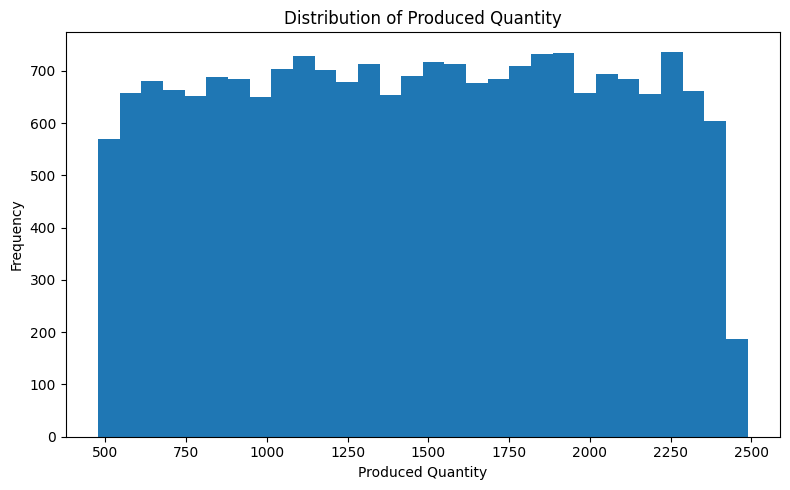

In [76]:
# ==========================================
# Production Quantity Distribution
# ==========================================

plt.figure(figsize=(8, 5))

plt.hist(clean_df["Produced_Qty"], bins=30)

plt.title("Distribution of Produced Quantity")
plt.xlabel("Produced Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9.2 Efficiency Percentage Distribution

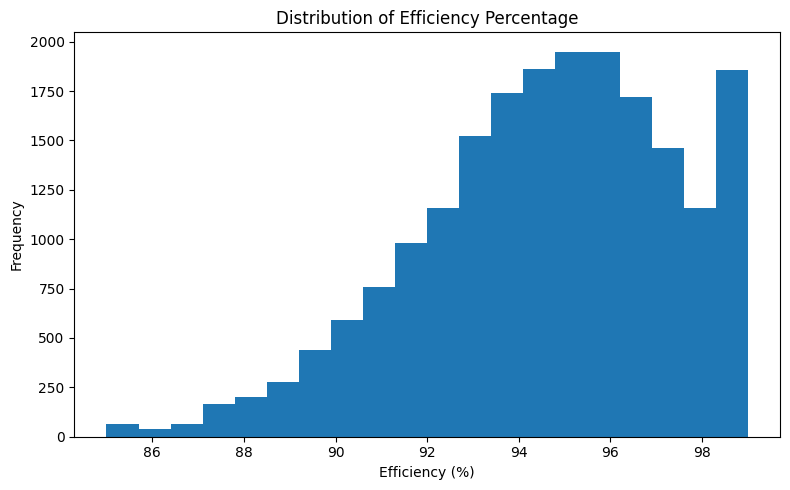

In [77]:
# ==========================================
# Efficiency Percentage Distribution
# ==========================================

plt.figure(figsize=(8, 5))

plt.hist(clean_df["Efficiency_Percent"], bins=20)

plt.title("Distribution of Efficiency Percentage")
plt.xlabel("Efficiency (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9.3 Production by Shift

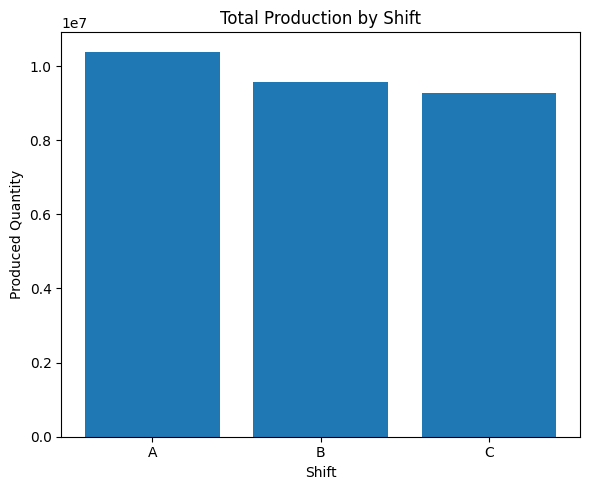

In [78]:
# ==========================================
# Production by Shift
# ==========================================

shift_production = clean_df.groupby("Shift")["Produced_Qty"].sum()

plt.figure(figsize=(6, 5))

plt.bar(shift_production.index, shift_production.values)

plt.title("Total Production by Shift")
plt.xlabel("Shift")
plt.ylabel("Produced Quantity")

plt.tight_layout()
plt.show()

### 9.4 Average Efficiency by Production Line

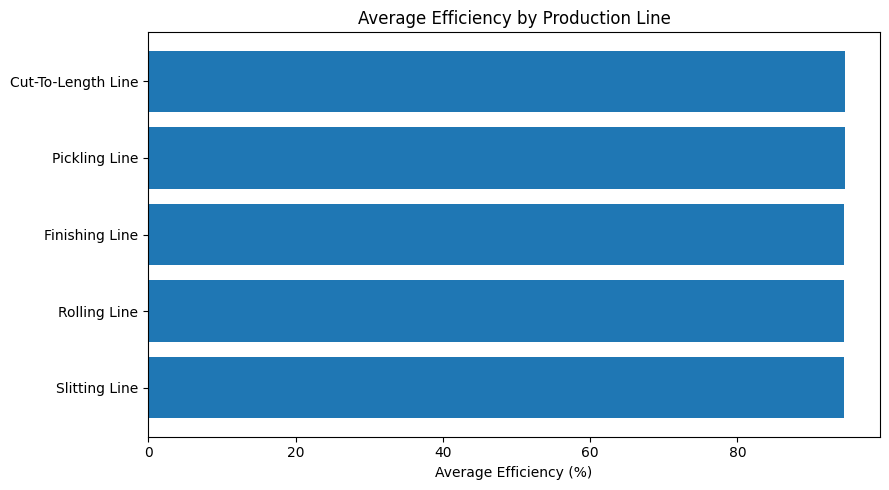

In [79]:
# ==========================================
# Average Efficiency by Production Line
# ==========================================

efficiency = (
    clean_df
    .groupby("Production_Line")["Efficiency_Percent"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(efficiency.index, efficiency.values)

plt.title("Average Efficiency by Production Line")
plt.xlabel("Average Efficiency (%)")

plt.tight_layout()
plt.show()

### 9.5 Downtime Reason Frequency

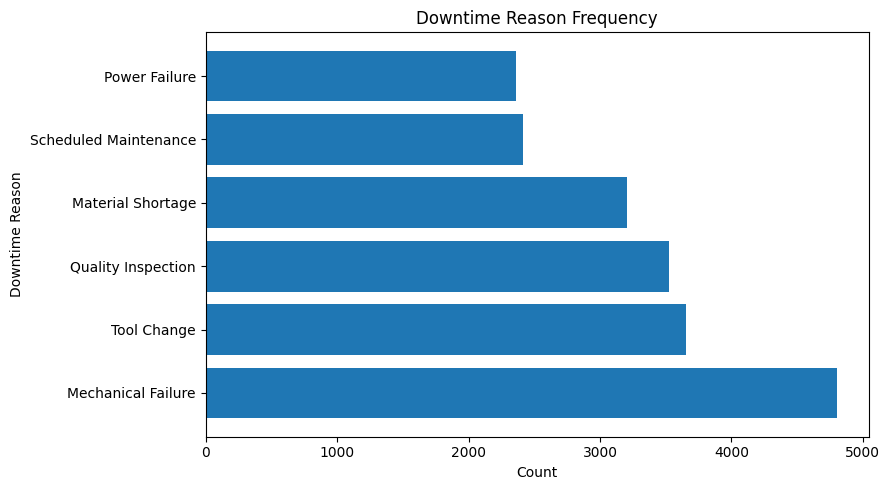

In [80]:
# ==========================================
# Downtime Reason Frequency
# ==========================================

downtime = clean_df["Downtime_Reason"].value_counts()

plt.figure(figsize=(9, 5))

plt.barh(downtime.index, downtime.values)

plt.title("Downtime Reason Frequency")
plt.xlabel("Count")
plt.ylabel("Downtime Reason")

plt.tight_layout()
plt.show()

### 9.6 Planned vs Produced Quantity

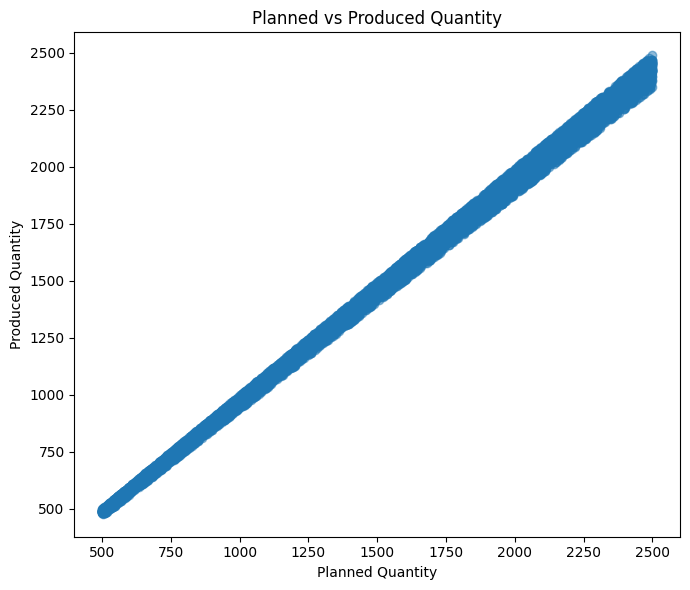

In [81]:
# ==========================================
# Planned vs Produced Quantity
# ==========================================

plt.figure(figsize=(7, 6))

plt.scatter(
    clean_df["Planned_Qty"],
    clean_df["Produced_Qty"],
    alpha=0.5
)

plt.title("Planned vs Produced Quantity")
plt.xlabel("Planned Quantity")
plt.ylabel("Produced Quantity")

plt.tight_layout()
plt.show()

### 9.7 Scrap Quantity Distribution

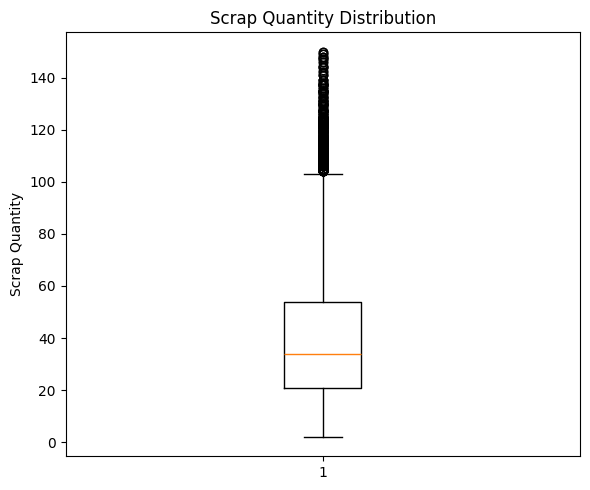

In [82]:
# ==========================================
# Scrap Quantity Distribution
# ==========================================

plt.figure(figsize=(6, 5))

plt.boxplot(clean_df["Scrap_Qty"])

plt.title("Scrap Quantity Distribution")
plt.ylabel("Scrap Quantity")

plt.tight_layout()
plt.show()

### 9.8 Monthly Production Trend

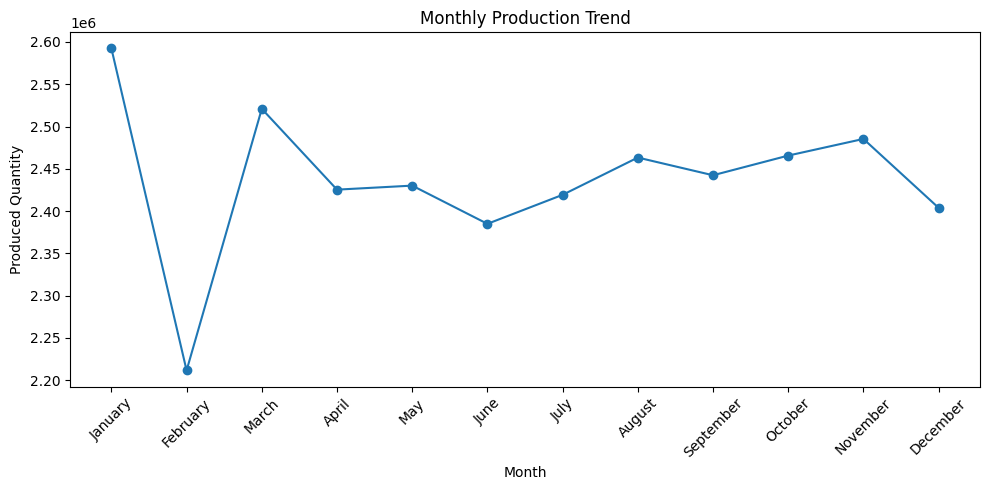

In [83]:
# ==========================================
# Monthly Production Trend
# ==========================================

monthly_production = (
    clean_df
    .groupby("Month")["Produced_Qty"]
    .sum()
    .reindex([
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ])
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_production.index,
    monthly_production.values,
    marker="o"
)

plt.title("Monthly Production Trend")
plt.xlabel("Month")
plt.ylabel("Produced Quantity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Export Clean Dataset

Export the cleaned and feature-engineered dataset for use in SQL, Excel, and Power BI.

In [84]:
# ==========================================
# Export Clean Dataset
# ==========================================

clean_df.to_csv(
    "manufacturing_cleaned.csv",
    index=False
)

print("Clean dataset exported successfully.")

Clean dataset exported successfully.


## 11. Project Summary

The manufacturing production dataset was successfully cleaned, validated, and enhanced for business analysis.

### Key Tasks Completed

- Imported and explored the raw dataset.
- Assessed data quality issues.
- Removed duplicate records.
- Resolved missing values.
- Converted data types.
- Standardized inconsistent text values.
- Removed invalid production records.
- Engineered analytical features.
- Validated the cleaned dataset.
- Created technical visualizations using Matplotlib.
- Exported the final cleaned dataset for SQL, Excel, and Power BI.

The exported dataset is now ready for downstream analysis, dashboard development, and business reporting.

## Next Steps

The cleaned dataset exported in this notebook will be used in the remaining stages of the project:

1. SQL
   - Business analysis
   - KPI calculations
   - Advanced SQL queries

2. Microsoft Excel
   - Pivot Tables
   - Pivot Charts
   - Interactive business reports

3. Power BI
   - Data modeling
   - DAX measures
   - Interactive dashboard